# 7. The generative pipeline

`clone_tree`, `gscale_tree`, `dscam_tree` and `spines_tree` synthesise new
morphologies from the statistics of real ones, rather than loading or editing
an existing reconstruction. Given a *group* of measured cells, `clone_tree`
grows fresh trees that share the group's size, shape and branching
statistics; `dscam_tree` and `spines_tree` then modify a single tree's
geometry to model specific biology.

This is the one part of `pynetrees` that draws from a random number
generator throughout, so every call below is seeded (`rng=`) for
reproducibility -- see [`docs/concepts.md`](../docs/concepts.md).

In [1]:
import numpy as np
import pyvista as pv
from IPython.display import Image

import pynetrees as pt

# ten real HSN dendrites, with proper axon/dendrite regions -- the group
# clone_tree learns from
group = pt.dLPTCs_trees()["dhsn"]
lengths = [pt.len_tree(t).sum() for t in group]
print(f"{len(group)} cells, {np.mean(lengths):.0f} +/- {np.std(lengths):.0f} um of cable each")

10 cells, 5693 +/- 1227 um of cable each


## Measuring a group: `gscale_tree`

`clone_tree` needs to know what "typical" looks like before it can grow
anything: how big each region is, where its branch and termination points
sit relative to the soma, and how much a traced path wanders beyond the
straight line between two points (the group's "wriggle"). `gscale_tree`
measures all of that, region by region, and rescales the input trees to the
group's mean extent so they can be compared and overlaid.

The returned `Spanning` is looked up by region name rather than by a
MATLAB-style parallel-array index.

In [2]:
spanning = pt.gscale_tree(group)
print("regions measured:", spanning.names)

for name in spanning.names:
    region = spanning[name]
    print(f"  {name:9s}: {region.mean_n:5.1f} +/- {region.std_n:4.1f} points, "
          f"mean extent {region.mean_extent.round(0)} um")

print(f"\nwriggle (amplitude, wavelength): "
      f"{spanning.wriggle.mean(axis=0).round(3)}")

regions measured: ['axon', 'dendrite']
  axon     :   1.0 +/-  0.0 points, mean extent [2. 2. 1.] um
  dendrite : 417.8 +/- 124.5 points, mean extent [283. 377.  76.] um

wriggle (amplitude, wavelength): [0.129 5.   ]


## Growing clones: `clone_tree`

For each region, `clone_tree` pools the group's rescaled branch and
termination points, scatters fresh target points at that density, and wires
them up with `MST_tree` -- then restores the group's taper, wriggle and
soma. `bf` is `MST_tree`'s balancing factor: `0` minimises total wire,
`1` minimises path length to the root.

A single input tree still works, but the variability that makes clones
differ from each other comes from the *spread* across the group -- so
cloning one tree alone yields near-identical clones. This is also slow:
each clone regrows its point cloud once to count how many targets survive
as branch/termination points, then again at the corrected count (see the
function's docstring for why).

real cells :    5693 um cable, 208.9 branch points (mean)
clones     :    9566 um cable, 222.0 branch points (mean)


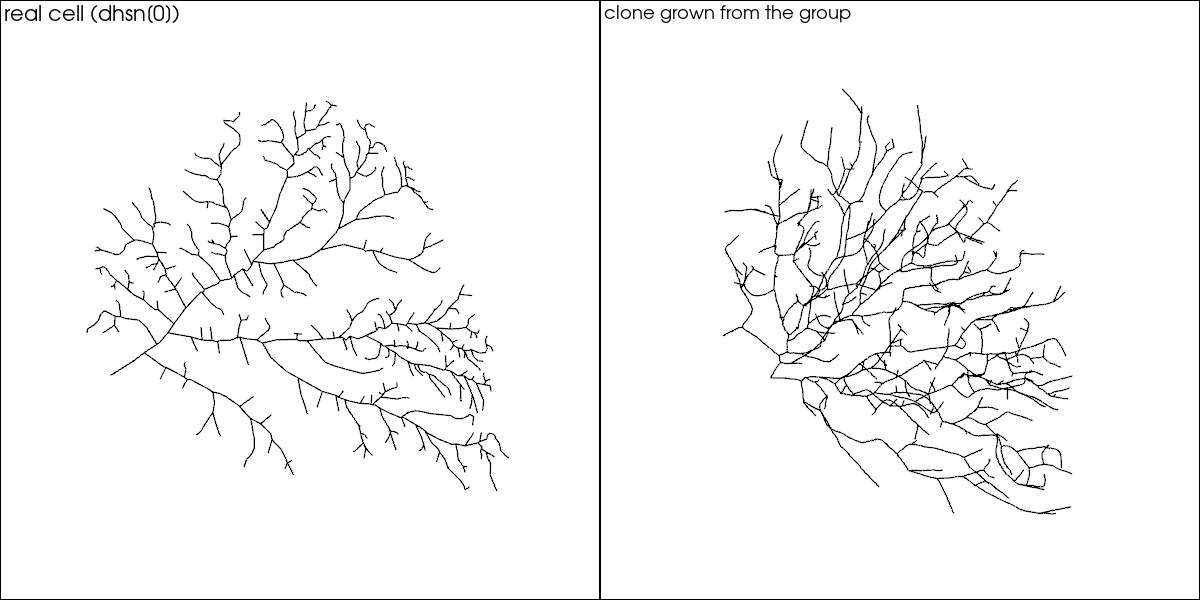

In [3]:
clones = pt.clone_tree(group, n=2, bf=0.4, rng=0)

clone_lengths = [pt.len_tree(c).sum() for c in clones]
clone_bpoints = [int(pt.B_tree(c).sum()) for c in clones]
real_bpoints = [int(pt.B_tree(t).sum()) for t in group]
print(f"real cells : {np.mean(lengths):7.0f} um cable, "
      f"{np.mean(real_bpoints):5.1f} branch points (mean)")
print(f"clones     : {np.mean(clone_lengths):7.0f} um cable, "
      f"{np.mean(clone_bpoints):5.1f} branch points (mean)")

pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1200, 600))
pl.subplot(0, 0)
pt.plot_tree(group[0], color="black", mode="line", plotter=pl)
pl.add_text("real cell (dhsn[0])", font_size=11)
pl.camera_position = "xy"
pl.subplot(0, 1)
pt.plot_tree(clones[0], color="black", mode="line", plotter=pl)
pl.add_text("clone grown from the group", font_size=11)
pl.camera_position = "xy"
pl.screenshot("tut07_clones.png")
pl.close()
Image("tut07_clones.png")

## Self-avoidance knockout: `dscam_tree`

DSCAM lets a neurite recognise and avoid its own siblings; without it,
branches that would normally repel each other clump together. `dscam_tree`
reproduces the effect crudely, as Bird, Deters & Cuntz (2021) do: repeatedly
pick a random node, find the nearest node that is not one of its ancestors
or descendants, and slide it -- with its whole subtree -- a fraction of the
way toward that neighbour.

It moves existing nodes without adding any, so segments that were evenly
spaced no longer are; resample afterwards if you need that back. Only
coordinates change -- topology and diameters are untouched.

mean branch-point spacing, before: 8.4 um
mean branch-point spacing, after : 6.4 um


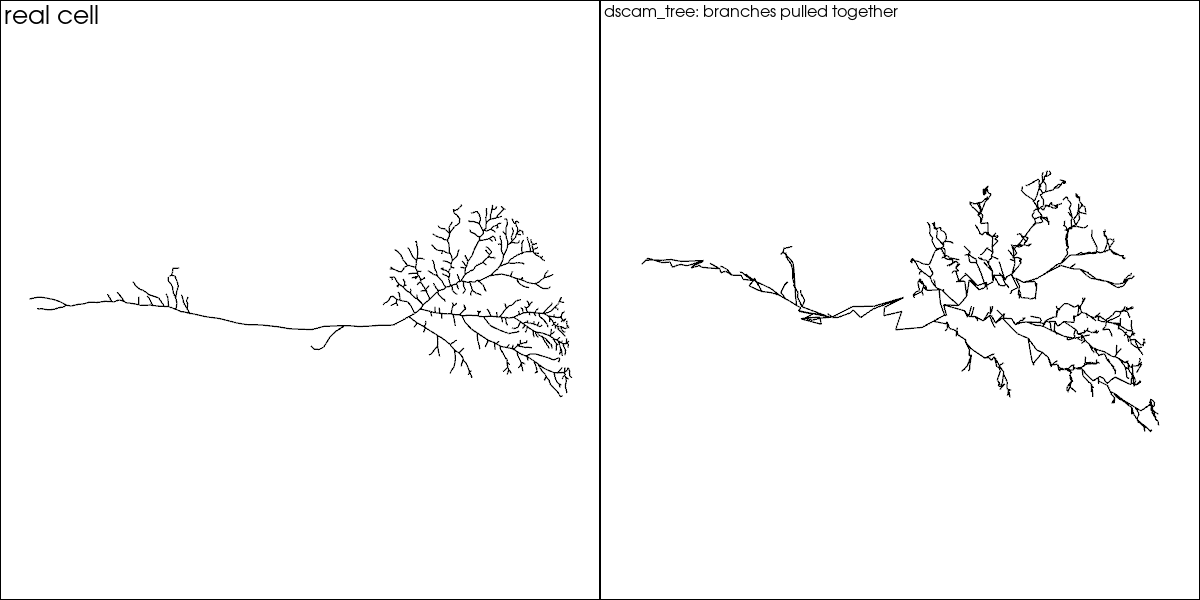

In [4]:
tree = pt.hsn_tree()
knocked_out = pt.dscam_tree(tree, iterations=3000, rng=0)

# how much closer did branches get? mean distance from each branch point to
# its nearest branch point that is not on its own root-to-tip path
from scipy.spatial import cKDTree

def nearest_unrelated_gap(t):
    bpoints = np.flatnonzero(pt.B_tree(t))
    coords = np.column_stack([t.X, t.Y, t.Z])
    tree_kd = cKDTree(coords[bpoints])
    dist, _ = tree_kd.query(coords[bpoints], k=2)
    return dist[:, 1].mean()  # nearest *other* branch point

print(f"mean branch-point spacing, before: {nearest_unrelated_gap(tree):.1f} um")
print(f"mean branch-point spacing, after : {nearest_unrelated_gap(knocked_out):.1f} um")

pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1200, 600))
pl.subplot(0, 0)
pt.plot_tree(tree, color="black", mode="line", plotter=pl)
pl.add_text("real cell", font_size=11)
pl.camera_position = "xy"
pl.subplot(0, 1)
pt.plot_tree(knocked_out, color="black", mode="line", plotter=pl)
pl.add_text("dscam_tree: branches pulled together", font_size=11)
pl.camera_position = "xy"
pl.screenshot("tut07_dscam.png")
pl.close()
Image("tut07_dscam.png")

## Adding spines: `spines_tree`

Each spine is two extra nodes -- a **neck** standing off the dendrite by a
length drawn from `N(neck_length, neck_length_std)`, and a **head** one
`head_diameter` further out along the same direction, so the head's surface
area comes out roughly right. Direction is perpendicular to the local
dendrite, at a uniformly random angle around it.

`spines` can be a count (place them at random nodes), an explicit array of
node indices, or an `(n, 3)` array of exact neck coordinates.
`separate_regions=True` labels necks and heads as two regions
(`spine_neck`, `spine_head`) instead of one combined `spines` region.

119 nodes -> 169 nodes (+25 heads, +25 necks)
regions now: ['dendrite', 'spine_neck', 'spine_head']


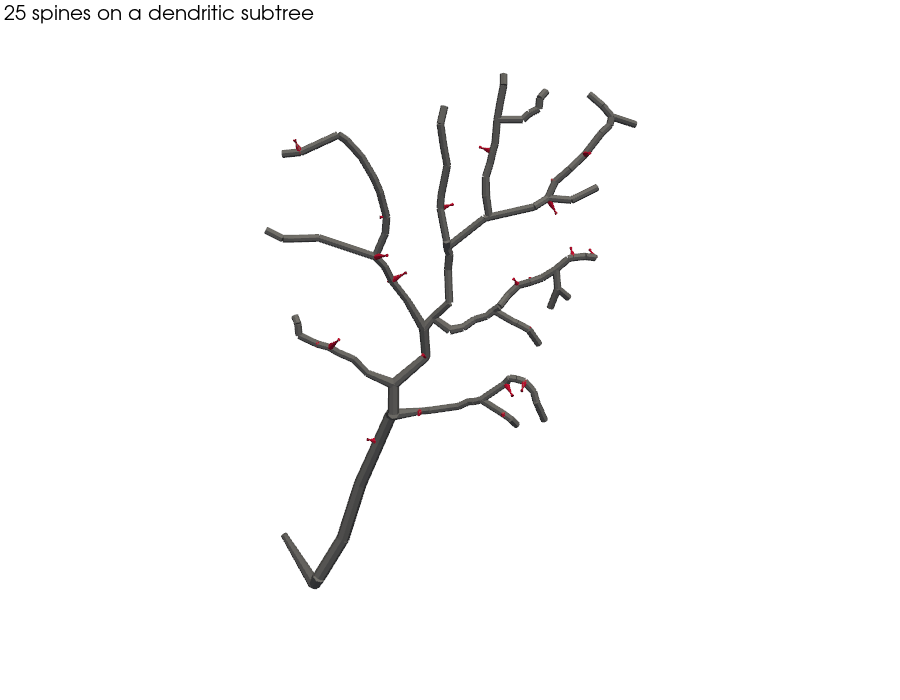

In [5]:
sub = pt.sub_tree(tree, 252).tree   # a 119-node terminal cluster, zoomed in
spined, heads, necks = pt.spines_tree(
    sub, spines=25, neck_diameter=0.3, head_diameter=0.6,
    separate_regions=True, rng=0, full_output=True,
)
print(f"{sub.n_nodes} nodes -> {spined.n_nodes} nodes "
      f"(+{len(heads)} heads, +{len(necks)} necks)")
print("regions now:", spined.rnames)

pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pt.plot_tree(spined, color="gray", mode="tube", plotter=pl)
pt.plot_tree(spined, color="crimson", mode="tube", plotter=pl,
             nodes=np.concatenate([heads, necks]))
pl.add_text(f"{len(heads)} spines on a dendritic subtree", font_size=11)
pl.camera_position = "xy"
pl.screenshot("tut07_spines.png")
pl.close()
Image("tut07_spines.png")

## Building blocks

`clone_tree` and `spines_tree` are built on smaller, independently useful
pieces:

- **`rpoints_tree`** draws random points from a density grid (usually a
  `gdens_tree` result) -- the "scatter fresh targets at this density" step
  `clone_tree` runs per region.
- **`PP_generator_tree`** scatters points with a *prescribed* degree of
  spatial regularity (its Clark-Evans ratio), useful as a synthetic contact-
  point target when the arrangement of the points is itself under study.
- **`in_hull`** tests points against a 2D polygon boundary, e.g. a
  `hull_tree(..., dim=2)` outline.

In [6]:
# rpoints_tree: resample the real cell's own density at higher resolution
grid = pt.gdens_tree(tree, sr=15.0)
resampled = pt.rpoints_tree(grid, n=5000, rng=0)
print(f"gdens_tree: {grid.counts.sum()} nodes across {grid.counts.size} voxels")
print(f"rpoints_tree: {len(resampled)} points redrawn from that density")

# PP_generator_tree: ask for a mildly over-dispersed point cloud and check
# it actually lands near the requested Clark-Evans ratio
points, n_iter, history = pt.PP_generator_tree(
    n=200, R=1.3, rng=0, full_output=True,
)
print(f"PP_generator_tree: target R=1.3, reached R={history[-1]:.3f} "
      f"in {n_iter} iterations")

gdens_tree: 1290.0 nodes across 14400 voxels
rpoints_tree: 5000 points redrawn from that density


PP_generator_tree: target R=1.3, reached R=1.297 in 19 iterations


This was the last of the numbered tutorials. For a live, rotatable 3D view
instead of the static screenshots used throughout 01–07, see
[`plot.ipynb`](plot.ipynb); for a task-oriented index across everything,
see [`docs/guide.md`](../docs/guide.md).